In [22]:
import pandas as pd
import numpy as np

In [23]:
processed = pd.read_csv("dataset/processed/spoofing-merged-gps-only.csv")
processed.head()

,timestamp,q[0],q[1],q[2],q[3],delta_q_reset[0],delta_q_reset[1],delta_q_reset[2],delta_q_reset[3],quat_reset_counter,...,v_z_valid,xy_reset_counter,z_reset_counter,vxy_reset_counter,vz_reset_counter,heading_reset_counter,xy_global,z_global,dist_bottom_valid,label
0,258725029,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
1,258842609,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
2,258847608,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
3,258852607,-0.325204,0.010556,-0.006517,0.945562,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
4,258902598,-0.325214,0.010552,-0.006501,0.945559,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign


In [24]:
processed.describe()

,timestamp,q[0],q[1],q[2],q[3],delta_q_reset[0],delta_q_reset[1],delta_q_reset[2],delta_q_reset[3],quat_reset_counter,...,v_xy_valid,v_z_valid,xy_reset_counter,z_reset_counter,vxy_reset_counter,vz_reset_counter,heading_reset_counter,xy_global,z_global,dist_bottom_valid
count,3.622000e+03,3622.000000,3622.000000,3622.000000,3622.000000,3.622000e+03,3.622000e+03,3.622000e+03,3.622000e+03,3622.0,...,3622.000000,3622.0,3622.0,3622.0,3622.0,3622.0,3622.0,3622.0,3622.0,3622.000000
mean,3.273061e+08,-0.373956,0.009302,-0.047475,0.865923,9.999948e-01,-4.610000e-10,1.580000e-09,3.237385e-03,3.0,...,0.998205,1.0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,0.050663
std,3.905689e+07,0.094026,0.042029,0.209995,0.230885,1.110376e-16,5.170593e-26,4.136474e-25,1.301222e-18,0.0,...,0.038685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.218900
min,2.587250e+08,-0.993977,-0.134411,-0.979830,-0.317683,9.999948e-01,-4.610000e-10,1.580000e-09,3.237385e-03,3.0,...,0.000000,1.0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,0.000000
25%,2.942138e+08,-0.375743,-0.003523,-0.010822,0.925623,9.999948e-01,-4.610000e-10,1.580000e-09,3.237385e-03,3.0,...,1.000000,1.0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,0.000000
50%,3.274473e+08,-0.372003,0.000271,-0.002302,0.927433,9.999948e-01,-4.610000e-10,1.580000e-09,3.237385e-03,3.0,...,1.000000,1.0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,0.000000
75%,3.611400e+08,-0.368555,0.009648,0.003119,0.928995,9.999948e-01,-4.610000e-10,1.580000e-09,3.237385e-03,3.0,...,1.000000,1.0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,0.000000
max,3.951494e+08,0.050424,0.485572,0.393335,0.945653,9.999948e-01,-4.610000e-10,1.580000e-09,3.237385e-03,3.0,...,1.000000,1.0,2.0,0.0,2.0,1.0,3.0,1.0,1.0,1.000000


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

num_cols = processed.select_dtypes(include=['float64']).columns
cat_cols = processed.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

processed_array = preprocessor.fit_transform(processed)
new_columns = preprocessor.get_feature_names_out()
processed = pd.DataFrame(processed_array, columns=new_columns)
processed.columns = [col.split('__')[-1] for col in processed.columns]

In [26]:
processed.head()

,q[0],q[1],q[2],q[3],delta_q_reset[0],delta_q_reset[1],delta_q_reset[2],delta_q_reset[3],lat_x,lon_x,...,ref_alt,dist_bottom,eph,epv,evh,evv,xy_valid,v_xy_valid,dist_bottom_valid,label_malicious
0,0.640338,0.233822,0.708809,0.999928,0.0,0.0,0.0,0.0,0.005568,0.772727,...,0.0,0.000113,0.054924,0.048998,0.018169,0.017320,1.0,1.0,1.0,0.0
1,0.640338,0.233822,0.708809,0.999928,0.0,0.0,0.0,0.0,0.005568,0.772727,...,0.0,0.000113,0.054924,0.048998,0.018169,0.017320,1.0,1.0,1.0,0.0
2,0.640338,0.233822,0.708809,0.999928,0.0,0.0,0.0,0.0,0.005568,0.772727,...,0.0,0.000388,0.055180,0.050258,0.018880,0.017574,1.0,1.0,1.0,0.0
3,0.640341,0.233825,0.708810,0.999929,0.0,0.0,0.0,0.0,0.005568,0.772727,...,0.0,0.000663,0.055436,0.051518,0.019592,0.017828,1.0,1.0,1.0,0.0
4,0.640332,0.233818,0.708821,0.999926,0.0,0.0,0.0,0.0,0.005639,0.772727,...,0.0,0.000442,0.057198,0.052858,0.024372,0.018835,1.0,1.0,1.0,0.0


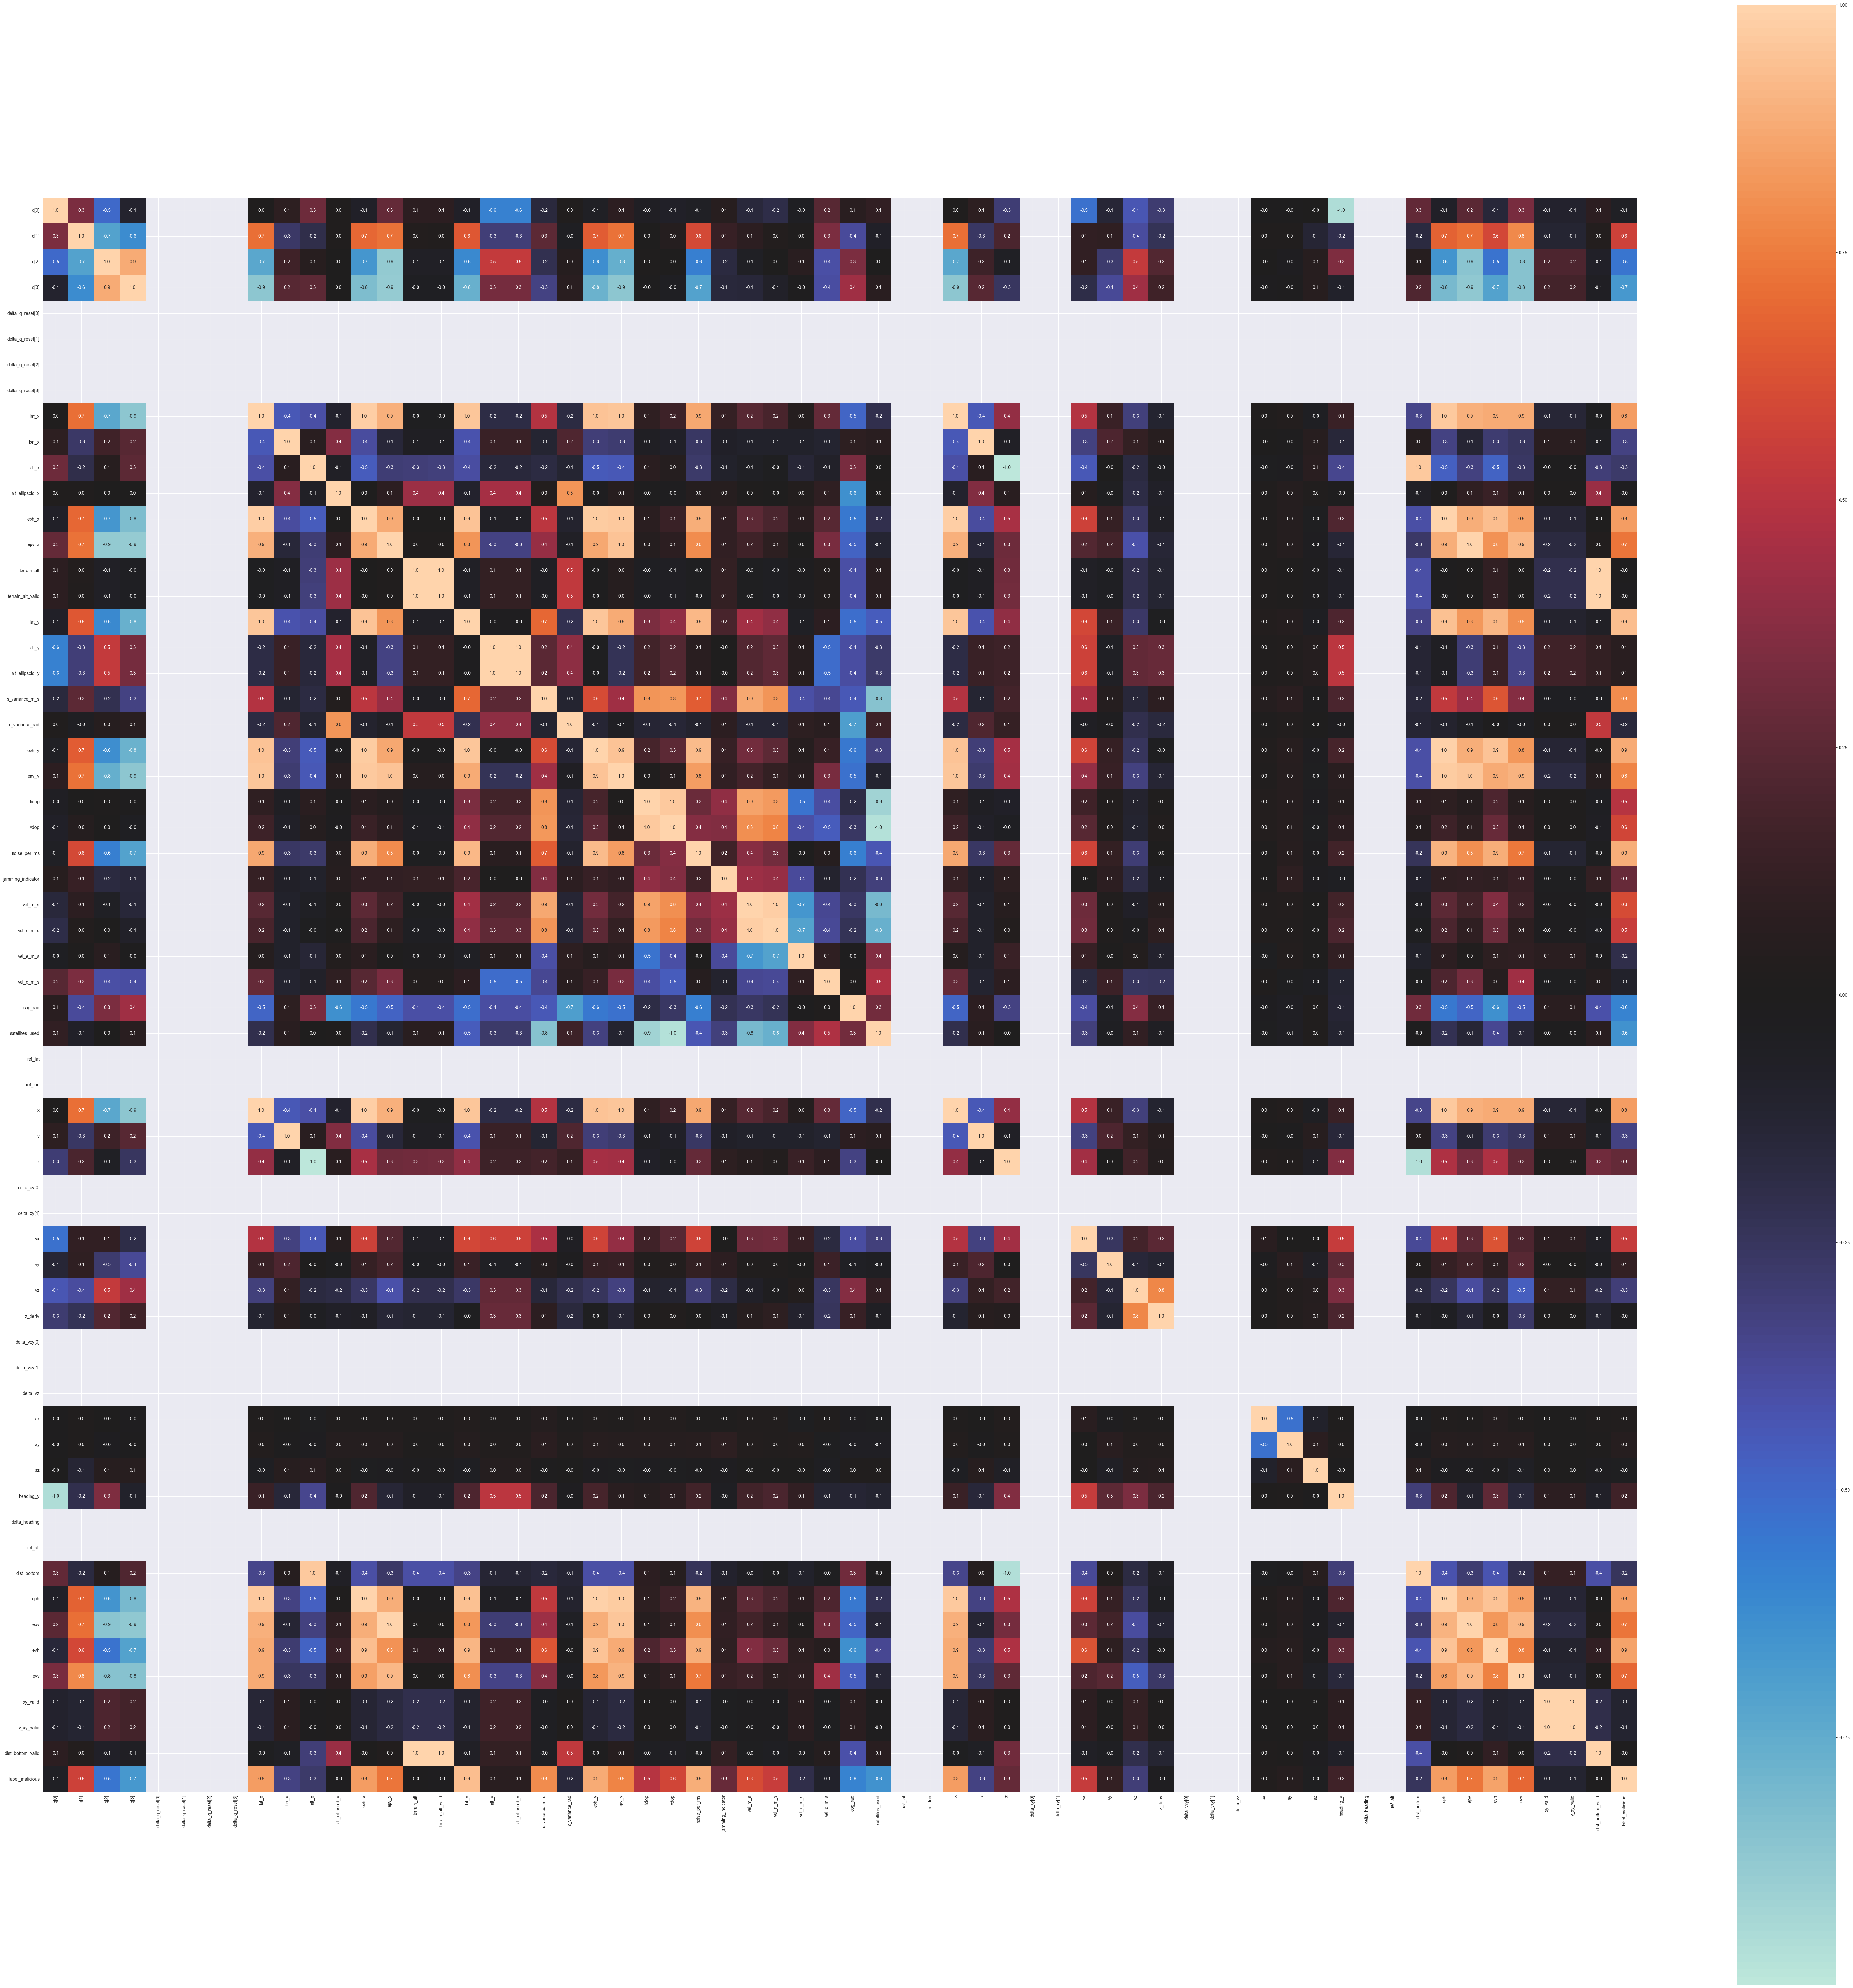

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(80,80))
correlation_matrix = processed.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, center=0, square=True, fmt=".1f")

plt.show()

In [20]:
processed.isna().sum()

num__q[0]                 0
num__q[1]                 0
num__q[2]                 0
num__q[3]                 0
num__delta_q_reset[0]     0
                         ..
num__evv                  0
num__xy_valid             0
num__v_xy_valid           0
num__dist_bottom_valid    0
cat__label_malicious      0
Length: 62, dtype: int64